In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Data File.csv')
df.head()

,Restaurant Name,Rating,Cuisine,Average Price,Average Delivery Time,Safety Measure,Location
0,Campus Bakers,4.3,"Bakery, Fast Food, Pizza, Sandwich, Burger",₹50 for one,36 min,Restaurant partner follows WHO protocol,Agra
1,Mama Chicken Mama Franky House,4,"North Indian, Mughlai, Rolls, Burger, Momos",₹50 for one,22 min,Follows all Max Safety measures to ensure your...,Agra
2,GMB - Gopika Sweets & Restaurant,4.2,"North Indian, South Indian, Chinese, Fast Food...",₹50 for one,27 min,Follows all Max Safety measures to ensure your...,Agra
3,Shree Bankey Bihari Misthan Bhandar,4.2,"Mithai, Street Food, South Indian, Chinese, Ic...",₹50 for one,28 min,Restaurant partner follows WHO protocol,Agra
4,Burger King,4.2,"Burger, Fast Food, Beverages",₹50 for one,26 min,Follows all Max Safety measures to ensure your...,Agra


In [29]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44891 entries, 0 to 44890
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Restaurant Name        44891 non-null  object
 1   Rating                 44891 non-null  object
 2   Cuisine                44872 non-null  object
 3   Average Price          44891 non-null  object
 4   Average Delivery Time  44891 non-null  object
 5   Safety Measure         44891 non-null  object
 6   Location               44891 non-null  object
dtypes: object(7)
memory usage: 2.4+ MB


,Restaurant Name,Rating,Cuisine,Average Price,Average Delivery Time,Safety Measure,Location
count,44891,44891,44872,44891,44891,44891,44891
unique,35688,28,17580,28,398,2,98
top,Baskin Robbins - Ice Cream Desserts,4,North Indian,₹100 for one,30 min,Follows all Max Safety measures to ensure your...,Kolkata
freq,70,5733,2403,13019,1715,25726,1296


In [30]:
# DATA CLEANING
# Convert Rating to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [31]:
# DATA CLEANING
# Convert Rating to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [32]:
# Clean Average Price
df['Average Price'] = df['Average Price'].str.replace('₹', '')
df['Average Price'] = df['Average Price'].str.extract('(\d+)').astype(float)

In [33]:
# Clean Delivery Time
df['Average Delivery Time'] = df['Average Delivery Time'].str.extract('(\d+)').astype(float)

In [34]:
# Split Cuisine
df['Cuisine'] = df['Cuisine'].str.split(', ')

In [35]:
# Simplify Safety Measure
df['Safety Measure'] = df['Safety Measure'].str.contains('WHO', case=False).map({
    True: 'WHO Protocol',
    False: 'Max Safety'
})

In [36]:
# Check missing values
df.isnull().sum()

# Drop missing
df = df.dropna()

In [37]:
# Remove duplicates
df = df.drop_duplicates()

TypeError: unhashable type: 'list'

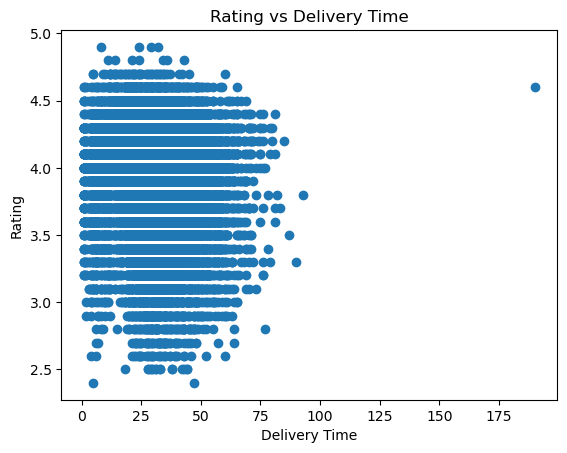

In [38]:
# Rating vs Delivery Time
plt.scatter(df['Average Delivery Time'], df['Rating'])
plt.xlabel('Delivery Time')
plt.ylabel('Rating')
plt.title('Rating vs Delivery Time')
plt.show()

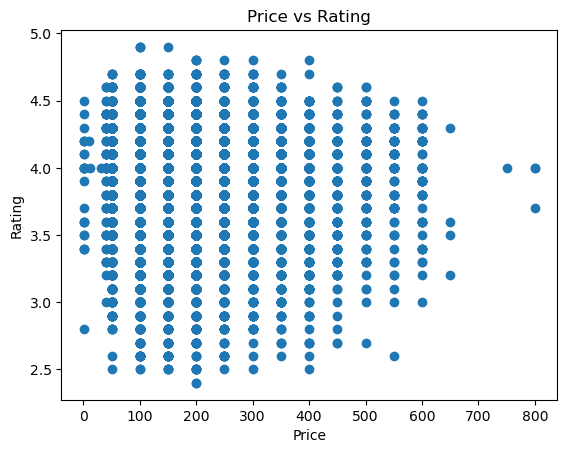

In [39]:
# Price vs Rating
plt.scatter(df['Average Price'], df['Rating'])
plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('Price vs Rating')
plt.show()

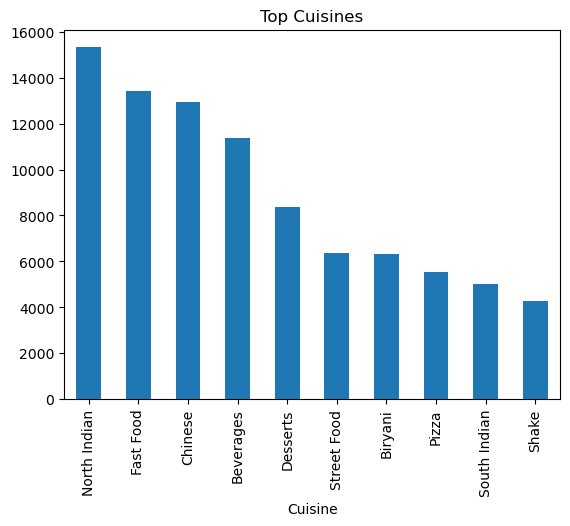

In [40]:
# Top Cuisines
df.explode('Cuisine')['Cuisine'].value_counts().head(10).plot(kind='bar')
plt.title('Top Cuisines')
plt.show()

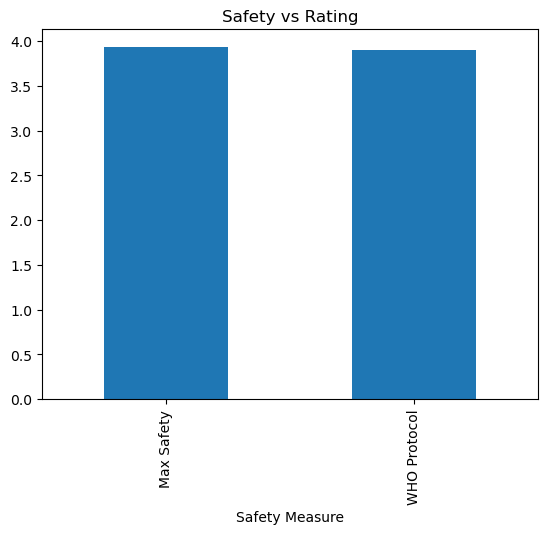

In [41]:
# Safety vs Rating
df.groupby('Safety Measure')['Rating'].mean().plot(kind='bar')
plt.title('Safety vs Rating')
plt.show()

In [42]:
# Top 5 restaurants
top5 = df.sort_values(by='Rating', ascending=False).head(5)
print("Top 5 Restaurants:\n", top5[['Restaurant Name', 'Rating']])

# Bottom 5 restaurants
bottom5 = df.sort_values(by='Rating', ascending=True).head(5)
print("\nBottom 5 Restaurants:\n", bottom5[['Restaurant Name', 'Rating']])

Top 5 Restaurants:
                       Restaurant Name  Rating
32964                   Rasoi Ghar Se     4.9
11965  Rambhai Special Butter Patties     4.9
27235                Hangyo Ice Cream     4.9
40328                      Cake Waves     4.9
39756                  Peni Ice Cream     4.8

Bottom 5 Restaurants:
             Restaurant Name  Rating
21343        Baba Biryani's     2.4
6872               The Vibe     2.4
39460      Navin Food Court     2.5
25657     Cake Shop Factory     2.5
26991  Shetty's Sai Kitchen     2.5


In [43]:
# Select features (X) and target (y)
X = df[['Average Price', 'Average Delivery Time']]
y = df['Rating']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.28153831581552774
RMSE: 0.3542077728861646
R² Score: 0.007603837641509847


In [52]:
# STATISTICAL OUTPUT

import pandas as pd
import numpy as np
from scipy import stats

# Load data
df = pd.read_csv('Data File.csv')

# Basic statistics
print("\n--- BASIC STATISTICS ---")
print(df.describe())

# Correlation matrix
print("\n--- CORRELATION MATRIX ---")
print(df.corr(numeric_only=True))

# Skewness & Kurtosis
print("\n--- SKEWNESS ---")
print(df.skew(numeric_only=True))

print("\n--- KURTOSIS ---")
print(df.kurtosis(numeric_only=True))

# Grouped statistics (by Safety Measure)
print("\n--- GROUPED STATS (Safety Measure vs Rating) ---")
print(df.groupby('Safety Measure')['Rating'].describe())

# T-test (Safety Measure impact on Rating)
group1 = df[df['Safety Measure'] == 'WHO Guidelines Followed']['Rating']
group2 = df[df['Safety Measure'] == 'Other']['Rating']

t_stat, p_value = stats.ttest_ind(group1, group2, nan_policy='omit')

print("\n--- T-TEST RESULT ---")
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# ANOVA (Cuisine effect on Rating)
df['Cuisine'] = df['Cuisine'].fillna('')
df_expanded = df.assign(Cuisine=df['Cuisine'].str.split(',')).explode('Cuisine')

groups = [group['Rating'].values for name, group in df_expanded.groupby('Cuisine') if len(group) > 1]

f_stat, p_value_anova = stats.f_oneway(*groups)

print("\n--- ANOVA RESULT (Cuisine vs Rating) ---")
print("F-Statistic:", f_stat)
print("P-Value:", p_value_anova)

# Confidence Interval for Rating
mean_rating = df['Rating'].mean()
sem = stats.sem(df['Rating'], nan_policy='omit')
ci = stats.t.interval(0.95, len(df['Rating'].dropna())-1, loc=mean_rating, scale=sem)

print("\n--- 95% CONFIDENCE INTERVAL (Rating) ---")
print("Mean Rating:", mean_rating)
print("Confidence Interval:", ci)


--- BASIC STATISTICS ---
                            Restaurant Name Rating       Cuisine  \
count                                 44891  44891         44872   
unique                                35688     28         17580   
top     Baskin Robbins - Ice Cream Desserts      4  North Indian   
freq                                     70   5733          2403   

       Average Price Average Delivery Time  \
count          44891                 44891   
unique            28                   398   
top     ₹100 for one                30 min   
freq           13019                  1715   

                                           Safety Measure Location  
count                                               44891    44891  
unique                                                  2       98  
top     Follows all Max Safety measures to ensure your...  Kolkata  
freq                                                25726     1296  

--- CORRELATION MATRIX ---
Empty DataFrame
Columns: []
I

C:\Users\sujal\anaconda3\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


TypeError: unsupported operand type(s) for /: 'str' and 'int'